## Example-1

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Create dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain', 'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast', 'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Num_Players': [52, 39, 43, 37, 28, 19, 43, 47, 56, 33, 49, 23, 42, 13, 33, 29, 25, 51, 41, 14, 34, 29, 49, 36, 57, 21, 23, 41]
}

df = pd.DataFrame(dataset_dict)

# One-hot encode 'Outlook' column
df = pd.get_dummies(df, columns=['Outlook'],prefix='',prefix_sep='')

# Convert 'Wind' column to binary
df['Wind'] = df['Wind'].astype(int)

# Rearrange columns
column_order = ['sunny', 'overcast', 'rain', 'Temperature', 'Humidity', 'Wind', 'Num_Players']
df = df[column_order]

# Split features and target
X, y = df.drop('Num_Players', axis=1), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

In [33]:
def calculate_split_mse(X_train, y_train, feature_name, split_point):
    # Create DataFrame and sort by feature
    analysis_df = pd.DataFrame({
        'feature': X_train[feature_name],
        'y_actual': y_train
    }).sort_values('feature')

    # Split data and calculate means
    left_mask = analysis_df['feature'] <= split_point
    left_mean = analysis_df[left_mask]['y_actual'].mean()
    right_mean = analysis_df[~left_mask]['y_actual'].mean()

    # Calculate squared differences
    analysis_df['squared_diff'] = np.where(
        left_mask,
        (analysis_df['y_actual'] - left_mean) ** 2,
        (analysis_df['y_actual'] - right_mean) ** 2
    )

    # Calculate MSEs and counts
    left_mse = analysis_df[left_mask]['squared_diff'].mean()
    right_mse = analysis_df[~left_mask]['squared_diff'].mean()
    n_left = sum(left_mask)
    n_right = len(analysis_df) - n_left

    # Calculate weighted average MSE
    weighted_mse = (n_left * left_mse + n_right * right_mse) / len(analysis_df)

    # Print results
    print(analysis_df)
    print(f"nResults for split at {split_point} on feature '{feature_name}':")
    print(f"Left child MSE (n={n_left}, mean={left_mean:.2f}): {left_mse:.2f}")
    print(f"Right child MSE (n={n_right}, mean={right_mean:.2f}): {right_mse:.2f}")
    print(f"Weighted average MSE: {weighted_mse:.2f}")

# Example usage:
calculate_split_mse(X_train, y_train, 'Temperature', 73.5)

    feature  y_actual  squared_diff
6      64.0        43       95.0625
5      65.0        19      203.0625
4      68.0        28       27.5625
8      69.0        56      517.5625
3      70.0        37       14.0625
13     71.0        13      410.0625
7      72.0        47      189.0625
11     72.0        23      105.0625
9      75.0        33      100.0000
10     75.0        49       36.0000
1      80.0        39       16.0000
12     81.0        42        1.0000
2      83.0        43        0.0000
0      85.0        52       81.0000
nResults for split at 73.5 on feature 'Temperature':
Left child MSE (n=8, mean=33.25): 195.19
Right child MSE (n=6, mean=43.00): 39.00
Weighted average MSE: 128.25


In [34]:
def evaluate_all_splits(X_train, y_train):
    """Evaluate all possible split points using midpoints for all features"""
    results = []

    for feature in X_train.columns:
        data = pd.DataFrame({'feature': X_train[feature], 'y_actual': y_train})
        splits = [(a + b)/2 for a, b in zip(sorted(data['feature'].unique())[:-1], 
                                          sorted(data['feature'].unique())[1:])]

        for split in splits:
            left_mask = data['feature'] <= split
            n_left = sum(left_mask)

            if not (0 < n_left < len(data)): continue

            left_mean = data[left_mask]['y_actual'].mean()
            right_mean = data[~left_mask]['y_actual'].mean()

            left_mse = ((data[left_mask]['y_actual'] - left_mean) ** 2).mean()
            right_mse = ((data[~left_mask]['y_actual'] - right_mean) ** 2).mean()

            weighted_mse = (n_left * left_mse + (len(data) - n_left) * right_mse) / len(data)

            results.append({'Feature': feature, 'Split_Point': split, 'Weighted_MSE': weighted_mse})

    return pd.DataFrame(results).round(2)

# Example usage:
results = evaluate_all_splits(X_train, y_train)
print(results)

        Feature  Split_Point  Weighted_MSE
0         sunny          0.5         82.20
1      overcast          0.5        151.49
2          rain          0.5         78.97
3   Temperature         64.5        149.14
4   Temperature         66.5        144.64
5   Temperature         68.5        136.48
6   Temperature         69.5        151.19
7   Temperature         70.5        151.15
8   Temperature         71.5        134.52
9   Temperature         73.5        128.25
10  Temperature         77.5        134.26
11  Temperature         80.5        133.02
12  Temperature         82.0        134.62
13  Temperature         84.0        135.20
14     Humidity         67.5        149.14
15     Humidity         72.5        144.06
16     Humidity         76.5        140.91
17     Humidity         79.0        135.86
18     Humidity         82.5        148.91
19     Humidity         87.5        151.19
20     Humidity         92.5        148.05
21     Humidity         95.5        151.52
22         

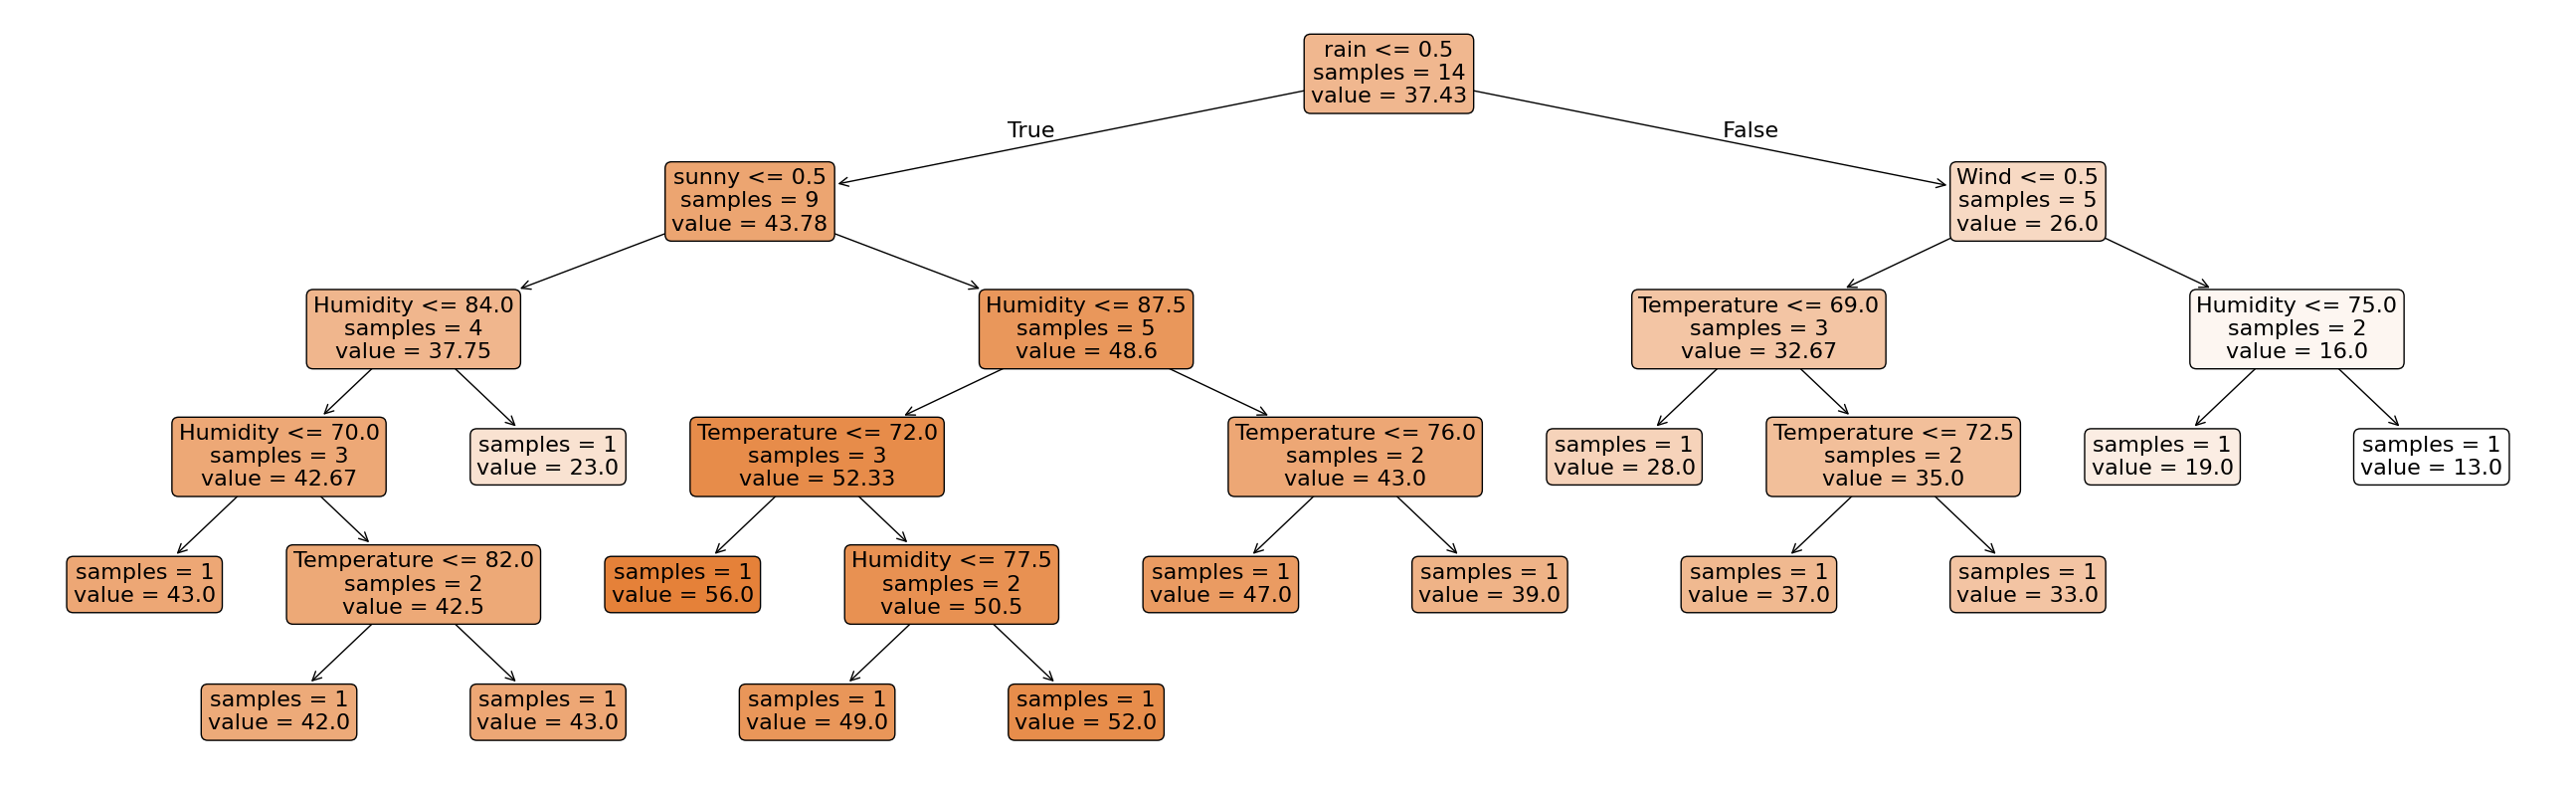

In [35]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train the model
regr = DecisionTreeRegressor(random_state=42)
regr.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, impurity=False, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

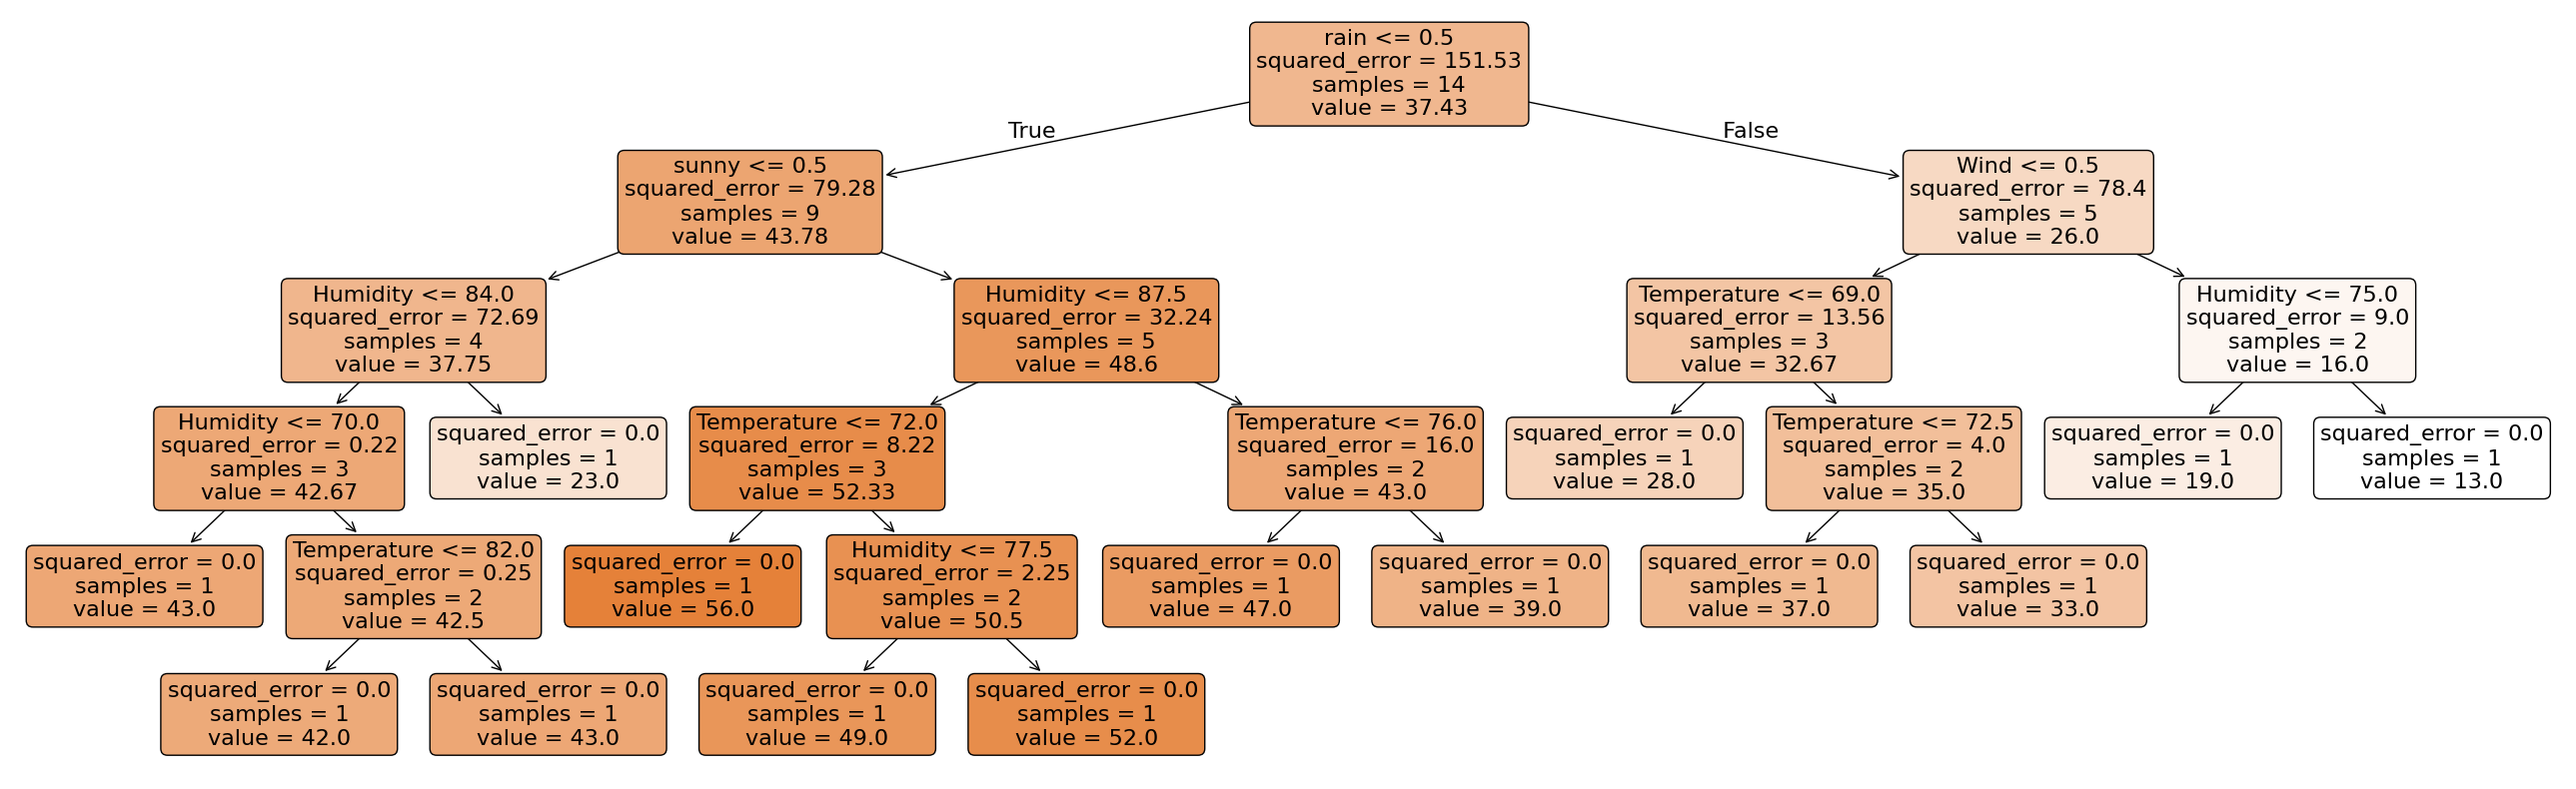

In [36]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train the model
regr = DecisionTreeRegressor(random_state=42)
regr.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, impurity=True, fontsize=16, precision=2)
plt.tight_layout()
plt.show()

In [37]:
# Compute the cost-complexity pruning path
tree = DecisionTreeRegressor(random_state=42)
effective_alphas = tree.cost_complexity_pruning_path(X_train, y_train).ccp_alphas
impurities = tree.cost_complexity_pruning_path(X_train, y_train).impurities

# Function to count leaf nodes
count_leaves = lambda tree: sum(tree.tree_.children_left[i] == tree.tree_.children_right[i] == -1 for i in range(tree.tree_.node_count))

# Train trees and count leaves for each complexity parameter
leaf_counts = [count_leaves(DecisionTreeRegressor(random_state=0, ccp_alpha=alpha).fit(X_train, y_train)) for alpha in effective_alphas]

# Create DataFrame with analysis results
pruning_analysis = pd.DataFrame({
    'total_leaf_impurities': impurities,
    'leaf_count': leaf_counts,
    'cost_function': [f"{imp:.3f} + {leaves}α" for imp, leaves in zip(impurities, leaf_counts)],
    'effective_α': effective_alphas
})

print(pruning_analysis)

    total_leaf_impurities  leaf_count cost_function  effective_α
0                0.000000          14   0.000 + 14α     0.000000
1                0.047619          12   0.048 + 12α     0.023810
2                0.369048          11   0.369 + 11α     0.321429
3                0.940476          10   0.940 + 10α     0.571429
4                2.226190           9    2.226 + 9α     1.285714
5                3.666667           8    3.667 + 8α     1.440476
6                5.952381           7    5.952 + 7α     2.285714
7                8.285714           6    8.286 + 6α     2.333333
8               15.752381           5   15.752 + 5α     7.466667
9               55.158730           3   55.159 + 3α    19.703175
10              78.968254           2   78.968 + 2α    23.809524
11             151.530612           1  151.531 + 1α    72.562358


## Example-2

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

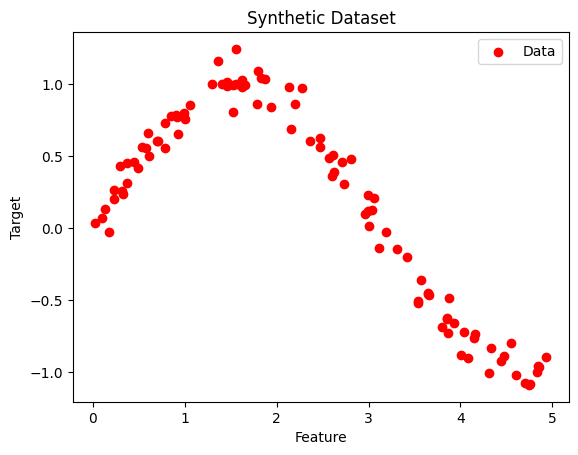

In [39]:
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

plt.scatter(X, y, color='red', label='Data')
plt.title("Synthetic Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [41]:
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [42]:
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.0151


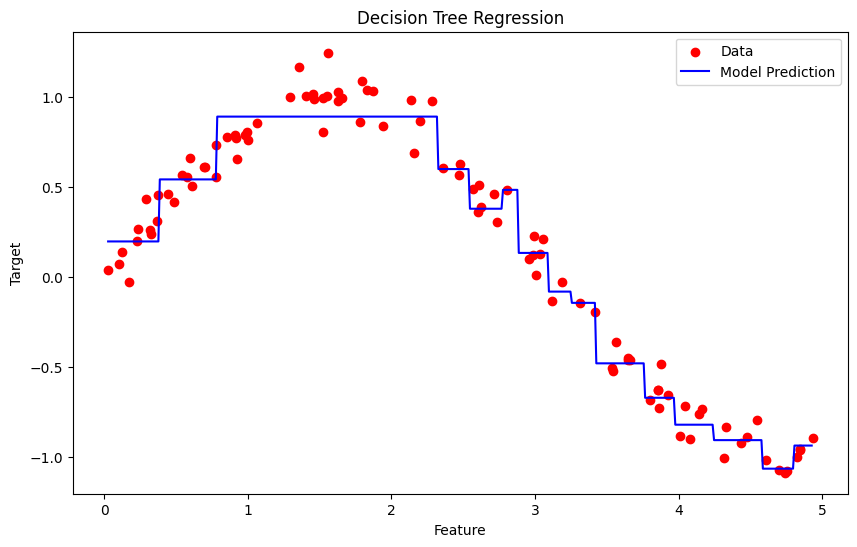

In [43]:
X_grid = np.arange(min(X.reshape(1, -1)[0]), max(X.reshape(1, -1)[0]), 0.01)[:, np.newaxis]
y_grid_pred = regressor.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

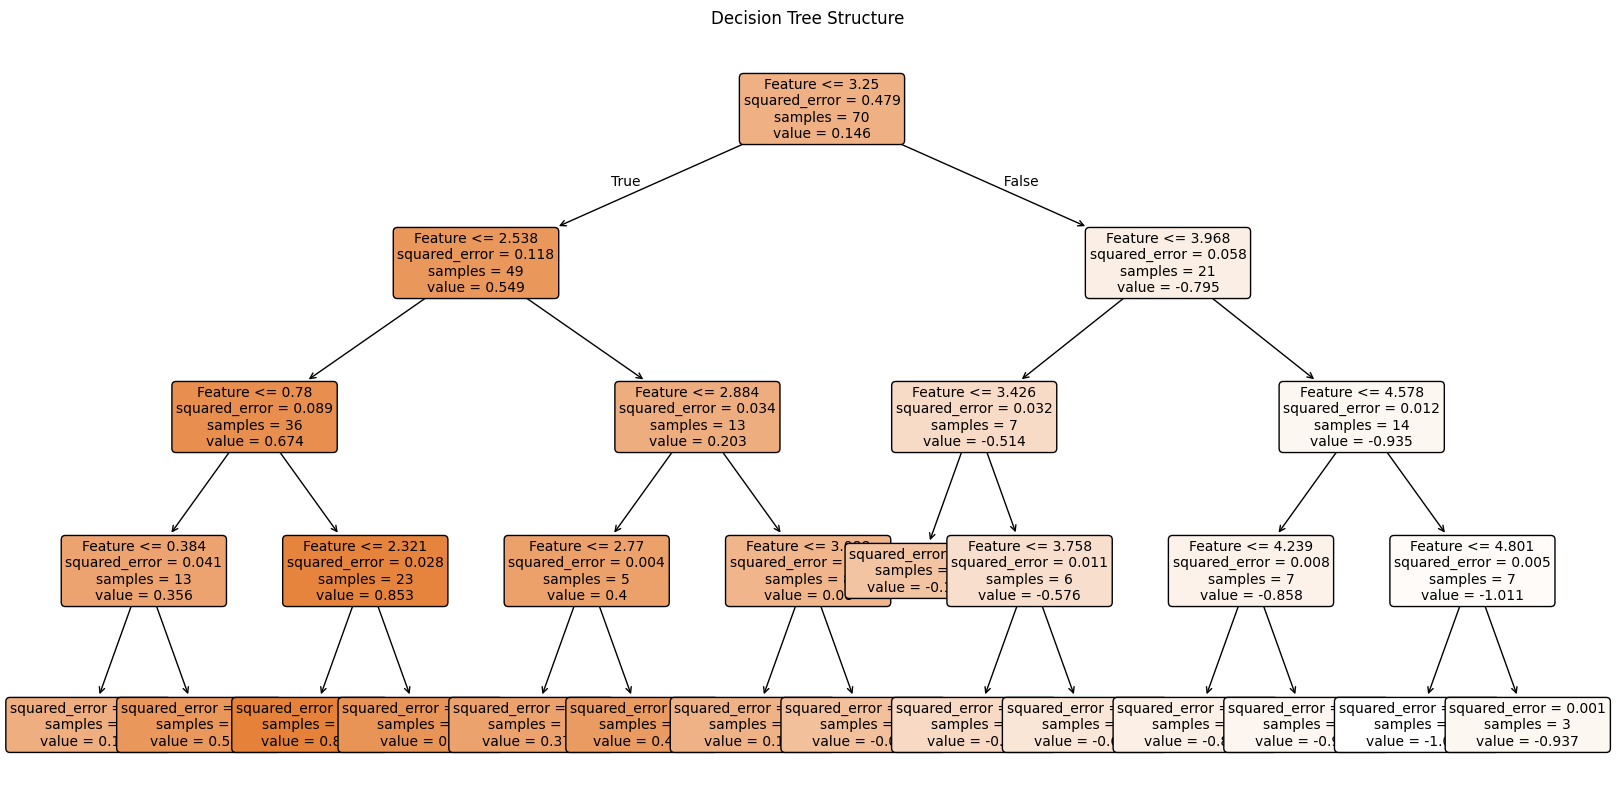

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    regressor,
    feature_names=["Feature"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()